#  Logistic Regression

## It's NOT Regression — It's Classification!

Despite the name, Logistic Regression is used for **classification** (yes/no, pass/fail, spam/not spam).

## The Sigmoid Function

Transforms any number to a value between 0 and 1.

sigmoid(x) = 1 / (1 + e^(-x))

- Input: -∞ to +∞
- Output: 0 to 1 (probability)

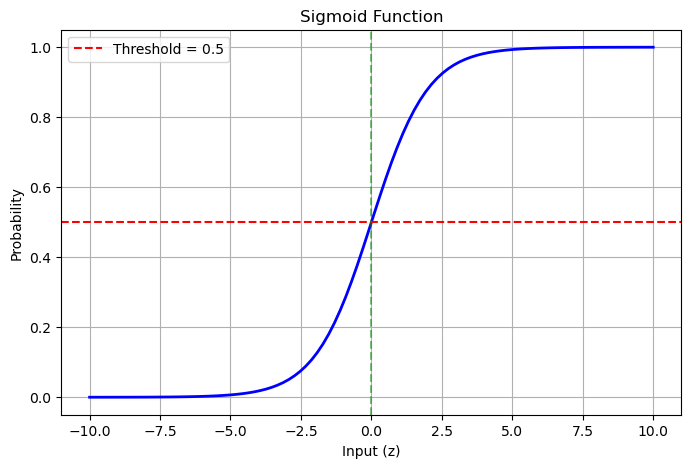

sigmoid(0) = 0.5
sigmoid(5) = 0.9933071490757153
sigmoid(-5) = 0.0066928509242848554


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Sigmoid function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Plot sigmoid
x = np.linspace(-10, 10, 100)
y = sigmoid(x)

plt.figure(figsize=(8, 5))
plt.plot(x, y, color='blue', linewidth=2)
plt.axhline(y=0.5, color='red', linestyle='--', label='Threshold = 0.5')
plt.axvline(x=0, color='green', linestyle='--', alpha=0.5)
plt.xlabel("Input (z)")
plt.ylabel("Probability")
plt.title("Sigmoid Function")
plt.legend()
plt.grid(True)
plt.show()

print("sigmoid(0) =", sigmoid(0))      # 0.5
print("sigmoid(5) =", sigmoid(5))      # ~0.99
print("sigmoid(-5) =", sigmoid(-5))    # ~0.01

## Example: Pass or Fail Based on Study Hours

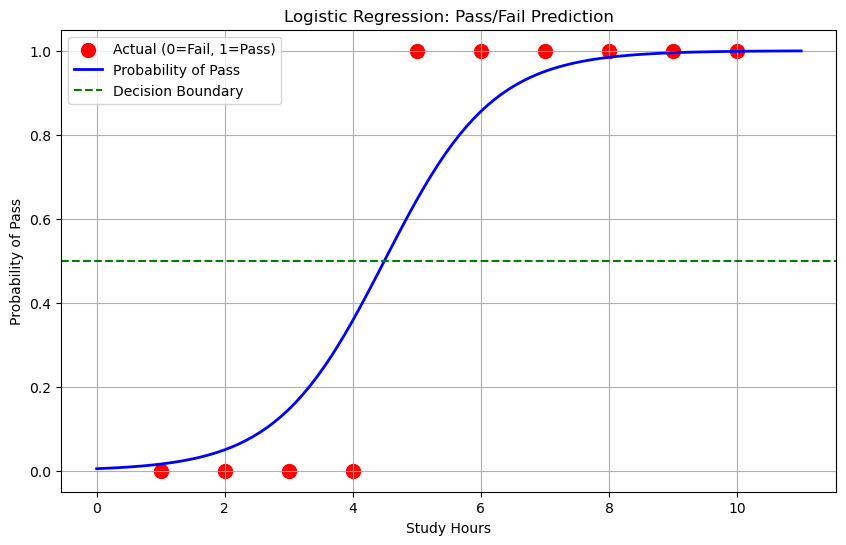

Probability of passing with 3.5 hours: 0.23597920183078397
Probability of passing with 7 hours: 0.9508262625358741
Prediction for 3.5 hours: Fail
Prediction for 7 hours: Pass


In [2]:
from sklearn.linear_model import LogisticRegression

# Data: study hours and result (0=Fail, 1=Pass)
study_hours = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)
result = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])  # 0=Fail, 1=Pass

# Train model
model = LogisticRegression()
model.fit(study_hours, result)

# Predict probabilities
hours_test = np.linspace(0, 11, 100).reshape(-1, 1)
probabilities = model.predict_proba(hours_test)[:, 1]  # Probability of Pass

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(study_hours, result, color='red', s=100, label='Actual (0=Fail, 1=Pass)')
plt.plot(hours_test, probabilities, color='blue', linewidth=2, label='Probability of Pass')
plt.axhline(y=0.5, color='green', linestyle='--', label='Decision Boundary')
plt.xlabel("Study Hours")
plt.ylabel("Probability of Pass")
plt.title("Logistic Regression: Pass/Fail Prediction")
plt.legend()
plt.grid(True)
plt.show()

# Predict for new students
print("Probability of passing with 3.5 hours:", model.predict_proba([[3.5]])[0][1])
print("Probability of passing with 7 hours:", model.predict_proba([[7]])[0][1])
print("Prediction for 3.5 hours:", "Pass" if model.predict([[3.5]])[0] == 1 else "Fail")
print("Prediction for 7 hours:", "Pass" if model.predict([[7]])[0] == 1 else "Fail")

## Confusion Matrix

| | Predicted: No | Predicted: Yes |
|---|---|---|
| **Actual: No** | True Negative (TN) | False Positive (FP) |
| **Actual: Yes** | False Negative (FN) | True Positive (TP) |

- **Accuracy**: (TP + TN) / Total
- **Precision**: TP / (TP + FP) → Of predicted yes, how many actually yes?
- **Recall**: TP / (TP + FN) → Of actual yes, how many did we catch?

Confusion Matrix:
 [[4 0]
 [0 6]]
Accuracy: 1.00
Precision: 1.00
Recall: 1.00


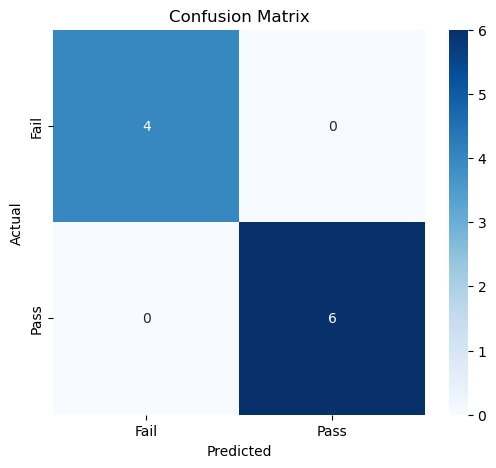

In [4]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

# Predictions on training data
y_pred = model.predict(study_hours)

# Confusion matrix
cm = confusion_matrix(result, y_pred)
print("Confusion Matrix:\n", cm)

# Metrics
print(f"Accuracy: {accuracy_score(result, y_pred):.2f}")
print(f"Precision: {precision_score(result, y_pred):.2f}")
print(f"Recall: {recall_score(result, y_pred):.2f}")

# Visualize confusion matrix
import seaborn as sns
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()